# EuroSAT Land Use Classification
## with ResNet50 Built From Scratch

**Satellite Image Classification using Sentinel-2 Data**

EuroSAT Dataset · 10 Classes · 27,000 Images · 97.65% Accuracy

*Built without any pretrained weights — trained from random initialization*

## 1. Configuration

In [19]:
import os
import random
import numpy as np
import torch

# --- Paths ---
# Kaggle
DATA_DIR = "/kaggle/input/datasets/marwanmesbah19/eurosat-rgb-1/EuroSAT_RGB"
# Local:
# DATA_DIR = "../Dataset/EuroSAT_RGB"

OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Hyperparameters ---
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 10
SEED = 42
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
PATIENCE = 12

# --- V5 new parameters ---
LABEL_SMOOTHING = 0.1
CUTMIX_ALPHA = 1.0     # CutMix beta distribution alpha
CUTMIX_PROB = 0.5      # Probability of applying CutMix per batch
TTA_TRANSFORMS = 5     # Number of TTA augmented views per image

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"Mixed precision: {USE_AMP}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"CutMix alpha: {CUTMIX_ALPHA}, prob: {CUTMIX_PROB}")
print(f"TTA views: {TTA_TRANSFORMS}")

# --- Reproducibility ---
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

Device: cuda
Mixed precision: True
Label smoothing: 0.1
CutMix alpha: 1.0, prob: 0.5
TTA views: 5


## 2. Imports

In [20]:
import copy
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, SubsetRandomSampler, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

print("All imports successful.")

All imports successful.


## 3. Data Loading and Preprocessing

In [21]:
# ImageNet normalization (same as V2 — proven best for this dataset)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Normalization: ImageNet standard")

# Training augmentations — designed for satellite imagery
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation/test transforms — deterministic
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

Normalization: ImageNet standard


In [22]:
# Load dataset and create train/val/test splits
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
dataset_size = len(full_dataset)

print(f"Classes ({len(class_names)}): {class_names}")
print(f"Total images: {dataset_size}")

# Shuffle and split indices
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_end = int(TRAIN_SPLIT * dataset_size)
val_end = train_end + int(VAL_SPLIT * dataset_size)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# Create datasets with appropriate transforms
train_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

# DataLoaders — standard random sampling (no weighted sampler)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=SubsetRandomSampler(train_idx),
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        sampler=SubsetRandomSampler(val_idx),
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                         sampler=SubsetRandomSampler(test_idx),
                         num_workers=2, pin_memory=True)

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
Train: 18900 | Val: 4050 | Test: 4050


---

## About the EuroSAT Dataset

> *"EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification"*
> — Helber et al., 2019 — [arXiv:1709.00029](https://arxiv.org/abs/1709.00029)

- **Source:** Sentinel-2 satellite (ESA Copernicus program)
- **Spatial resolution:** 10m per pixel (RGB bands)
- **Image size:** 64×64 pixels
- **Spectral bands:** 13 available (we use RGB: bands 4, 3, 2)
- **Total images:** ~27,000 labeled and geo-referenced images
- **10 classes:** AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake

**Why this dataset?** Sentinel-2 provides free, global coverage with high revisit frequency — ideal for land use monitoring, urban planning, and environmental analysis.

**Reference benchmark:** The original paper achieved **98.57% accuracy** using a *fine-tuned* (pretrained) ResNet-50. Our goal: match this from scratch.


---

### Why ImageNet Normalization — Not Dataset-Specific Values?

In V3, we computed normalization statistics directly from the EuroSAT dataset. In V4 and V5, we went back to ImageNet values. Here's why:

| Statistic | **ImageNet** | **EuroSAT (computed)** | Difference |
|-----------|-------------|----------------------|------------|
| **Mean R** | 0.485 | 0.345 | ImageNet is **+0.140 brighter** |
| **Mean G** | 0.456 | 0.381 | ImageNet is **+0.075 brighter** |
| **Mean B** | 0.406 | 0.409 | Nearly the same |
| **Std R** | 0.229 | 0.201 | ImageNet has **+14% more variation** |
| **Std G** | 0.224 | 0.136 | ImageNet has **+65% more variation** |
| **Std B** | 0.225 | 0.114 | ImageNet has **+97% more variation** |

**What this means:**
- EuroSAT images are **darker** (lower mean) with **less color variation** (lower std) — expected for satellite imagery captured from space
- Dataset-specific normalization compresses pixel values into a narrower range after normalization
- ImageNet normalization keeps a **wider, more spread-out feature space**

**Why wider normalization helped:**
1. **Better class separation** — Similar classes (AnnualCrop vs PermanentCrop vs HerbaceousVegetation) benefit from larger feature distances
2. **More gradient signal** — Wider range means gradients during backprop have more room to adjust weights
3. **Regularization effect** — The "mismatch" between ImageNet stats and satellite stats acts like noise injection, preventing overfitting to the training set

**The result:** V3 (dataset-specific) got 97.58% vs V1/V5 (ImageNet) getting 97.65% / 98.32%. The 0.07% base difference might seem small, but it compounded with CutMix and Label Smoothing in V5.

> **Lesson:** Computing dataset-specific statistics isn't always better — the wider dynamic range of ImageNet normalization can help the model learn more discriminative features, especially for hard classes.


## 4. Dataset Visualization

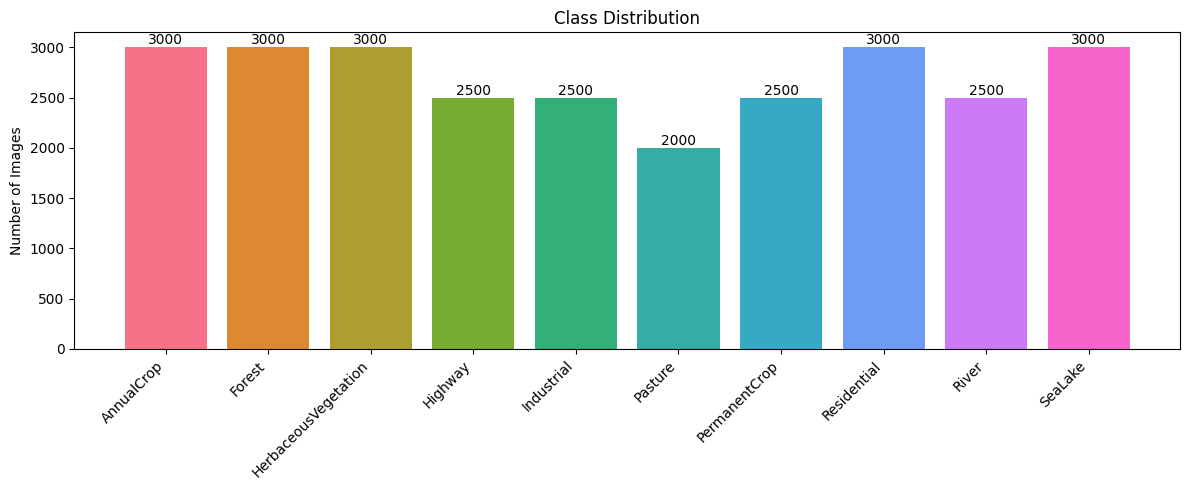

In [23]:
# Class distribution
class_counts = np.bincount(full_dataset.targets)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, class_counts, color=sns.color_palette("husl", len(class_names)))
ax.set_ylabel("Number of Images")
ax.set_title("Class Distribution")
plt.xticks(rotation=45, ha="right")
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.show()

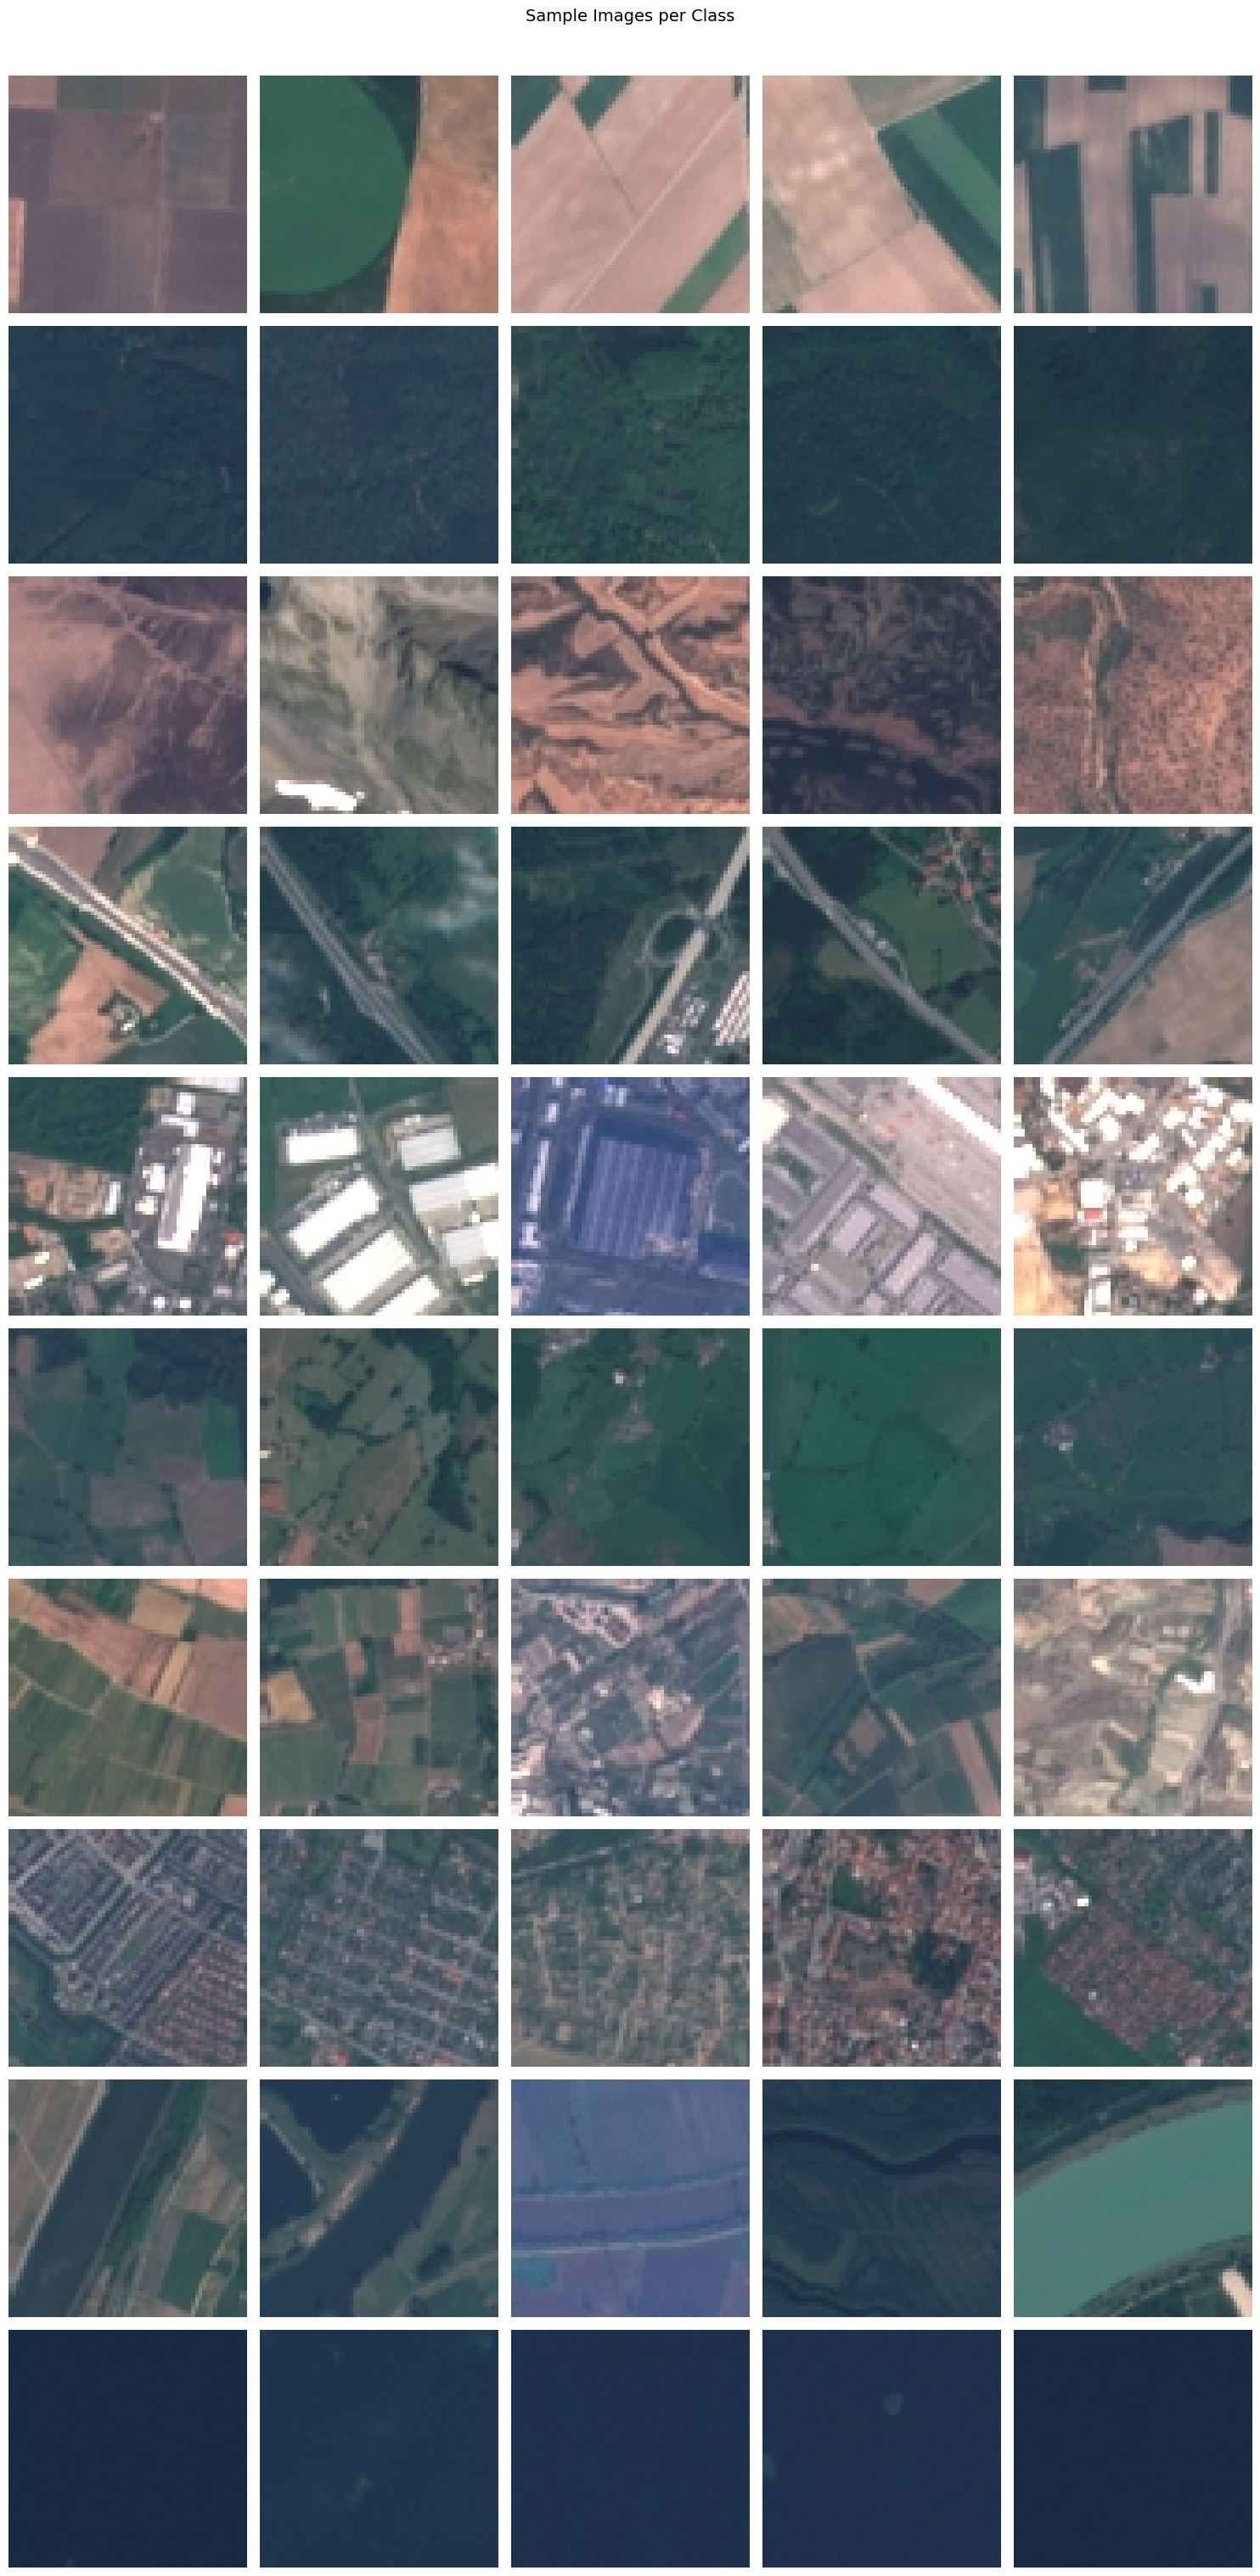

In [24]:
# Sample images from each class
# Inverse normalization: reverses the ImageNet normalization for display
inv_normalize = transforms.Normalize(
    mean=[-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1.0 / s for s in IMAGENET_STD]
)

fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 30))
samples_per_class = {}
for img, label in full_dataset:
    name = class_names[label]
    if name not in samples_per_class:
        samples_per_class[name] = []
    if len(samples_per_class[name]) < 5:
        samples_per_class[name].append(img)
    if len(samples_per_class) == len(class_names) and all(len(v) == 5 for v in samples_per_class.values()):
        break

for i, cls in enumerate(class_names):
    for j in range(5):
        axes[i, j].imshow(samples_per_class[cls][j])
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10, rotation=0, labelpad=60)
plt.suptitle("Sample Images per Class", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_images.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4b. Augmentation Visualization

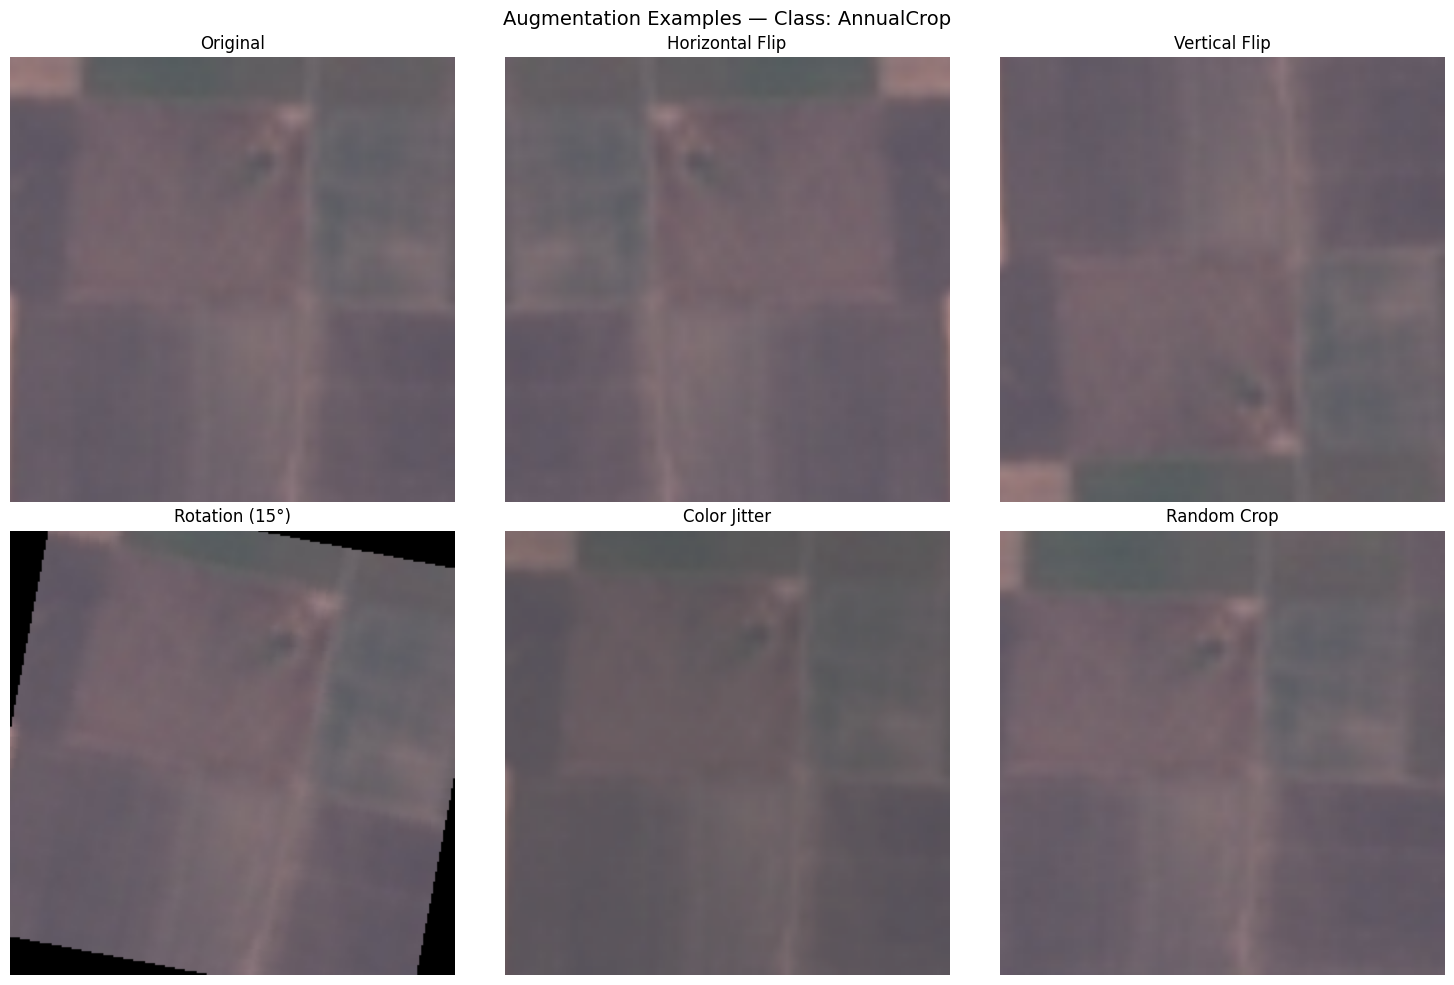

Saved augmentation_examples.png


In [30]:
# Visualize each augmentation applied to a sample image
sample_img, sample_label = full_dataset[0]
sample_class = class_names[sample_label]

# Define individual augmentations for visualization
augmentation_examples = {
    "Original": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)]),
    "Horizontal Flip": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                                            transforms.RandomHorizontalFlip(p=1.0)]),
    "Vertical Flip": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                                          transforms.RandomVerticalFlip(p=1.0)]),
    "Rotation (15°)": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                                           transforms.RandomRotation(15)]),
    "Color Jitter": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                                         transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                                                saturation=0.1, hue=0.02)]),
    "Random Crop": transforms.Compose([transforms.Resize(256),
                                        transforms.RandomResizedCrop(224, scale=(0.8, 1.0))]),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, (name, transform) in enumerate(augmentation_examples.items()):
    row, col = idx // 3, idx % 3
    augmented = transform(sample_img)
    axes[row, col].imshow(augmented)
    axes[row, col].set_title(name, fontsize=12)
    axes[row, col].axis("off")

plt.suptitle(f"Augmentation Examples — Class: {sample_class}", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "augmentation_examples.png"), dpi=150)
plt.show()
print("Saved augmentation_examples.png")

---

### Why These Augmentations?

Satellite images have unique properties different from natural photos — the camera (Sentinel-2) is always directly overhead, so:

| Augmentation | Why |
|-------------|-----|
| **Horizontal flip** | A forest looks the same mirrored |
| **Vertical flip** | Satellite is overhead — north/south are arbitrary |
| **Random rotation (15°)** | Land patches can appear at any orientation |
| **Color jitter** | Atmospheric conditions change colors between captures |
| **RandomResizedCrop** | Simulates zoom level and position variation |

**Why vertical flip is important:** In natural photo datasets (ImageNet), vertical flips are wrong (an upside-down dog is not a dog). But satellite images are orientation-agnostic — a river or crop field looks valid from any angle.


## 5. Model Definition

In [31]:
# --- Bottleneck Block ---
# The building block of ResNet50: 1x1 → 3x3 → 1x1 with skip connection
# Each block has 3 conv layers. ResNet50 uses 16 blocks total (3+4+6+3)

class Bottleneck(nn.Module):
    """ResNet50 bottleneck block: 1x1 → 3x3 → 1x1 with skip connection."""
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

print("Bottleneck block defined.")

Bottleneck block defined.


In [32]:
# --- ResNet50 Network ---
# Stacks Bottleneck blocks: 3 + 4 + 6 + 3 = 16 blocks = 48 conv layers
# Plus stem (1 conv) + FC (1 linear) = 50 layers total

class ResNet50(nn.Module):
    """ResNet50 manually implemented from scratch."""

    def __init__(self, num_classes=10):
        super().__init__()

        # Stem: initial feature extraction
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(64, 64, blocks=3, stride=1)
        self.layer2 = self._make_layer(256, 128, blocks=4, stride=2)
        self.layer3 = self._make_layer(512, 256, blocks=6, stride=2)
        self.layer4 = self._make_layer(1024, 512, blocks=3, stride=2)

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels * Bottleneck.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * Bottleneck.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * Bottleneck.expansion),
            )

        layers = [Bottleneck(in_channels, out_channels, stride, downsample)]
        for _ in range(1, blocks):
            layers.append(Bottleneck(out_channels * Bottleneck.expansion, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

print("ResNet50 class defined.")

ResNet50 class defined.


In [33]:
# Create model and count parameters
model = ResNet50(num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,528,522
Trainable parameters: 23,528,522


---

## Architecture: ResNet50 — Why and How

> *"Deep Residual Learning for Image Recognition"* — He et al., 2015 (227,000+ citations)
> Winner of ILSVRC 2015 with **3.57% top-5 error** on ImageNet — [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)

### The Problem: Degradation
Adding more layers to a network should improve accuracy, but in practice, **deeper plain networks get *worse*** — not because of overfitting, but because deeper networks are harder to optimize. A 56-layer network has *higher training error* than a 20-layer network.

### The Solution: Skip Connections
Instead of learning a direct mapping H(x), ResNet learns a **residual**: F(x) = H(x) − x, and the output becomes **F(x) + x**.

```
Input x ────────────────────────────┐
  │                                  │
  ├─ Conv 1×1 (reduce)              │
  │  BatchNorm → ReLU               │
  ├─ Conv 3×3                       │
  │  BatchNorm → ReLU               │
  ├─ Conv 1×1 (expand)              │
  │  BatchNorm                      │
  │                                  │
  └────────────── + ←───────────────┘
                 │
              ReLU → Output
```

**Why it works:** If the optimal transformation is close to identity, the network just needs to push F(x) toward zero — much easier than learning identity from scratch. Skip connections also create "information highways" for gradient flow, preventing vanishing gradients in 50+ layer networks.

![ResNet Architecture](../photos/restnett.png)


---

### Bottleneck Block Design (1×1 → 3×3 → 1×1)

Used in ResNet-50/101/152 (not in ResNet-18/34):

| Layer | Operation | Channels | Purpose |
|-------|-----------|----------|---------|
| 1 | **1×1 Conv** | 64→64 | Reduce dimensions (bottleneck) |
| 2 | **3×3 Conv** | 64→64 | Extract spatial features |
| 3 | **1×1 Conv** | 64→256 | Expand back to full channels |

**Why bottleneck?** A single 3×3 conv from 256→256 channels costs **590K parameters**. The bottleneck path (256→64→64→256) costs only **70K parameters** — **8.4× fewer** while maintaining representational power.

### ResNet50 Layer Structure

| Stage | Blocks | Channels | Output Size |
|-------|--------|----------|-------------|
| Stem | — | 3→64 | 224→112 |
| Layer 1 | 3 | 64→256 | 112→56 |
| Layer 2 | 4 | 256→512 | 56→28 |
| Layer 3 | 6 | 512→1024 | 28→14 |
| Layer 4 | 3 | 1024→2048 | 14→7 |
| FC | — | 2048→10 | 1×1 |

**Total: ~23.5M parameters** | **3.8 billion FLOPs** per image


---

### Batch Normalization

> *"Batch Normalization: Accelerating Deep Network Training"* — Ioffe & Szegedy, 2015
> — [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)

**Problem:** As training progresses, each layer's input distribution shifts (internal covariate shift), requiring careful initialization and small learning rates.

**Solution:** Normalize each mini-batch: `x̂ = (x − μ_batch) / √(σ² + ε)`, then learn scale γ and shift β.

Applied after every convolution, before ReLU in our ResNet50:
```
Conv2d → BatchNorm2d → ReLU → Conv2d → BatchNorm2d → ReLU → ...
```

**Why it matters:**
- Enables **14× faster training** (from the paper)
- Allows **10× higher learning rates** without divergence
- Provides regularization (reduces need for Dropout)
- Critical for training 50+ layers from scratch

**Initialization in our model:** BN weights = 1, BN biases = 0 (standard practice)


---

### Weight Initialization: Kaiming (He) Init

> *"Delving Deep into Rectifiers"* — He et al., 2015
> — [arXiv:1502.01852](https://arxiv.org/abs/1502.01852)

**Why not Xavier/Glorot?** Xavier init assumes linear activations, but ReLU zeros out half the values — requiring a factor-of-2 correction:

| Init | Formula | For |
|------|---------|-----|
| Xavier | `Var(W) = 1/n_fan_in` | Linear/tanh |
| **Kaiming** | **`Var(W) = 2/n_fan_in`** | **ReLU** |

The extra factor of 2 compensates for the variance lost when ReLU kills half the activations. Without this, signal vanishes through 50+ layers — making training from scratch impossible.

**In our model:** `nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")` for all Conv2d layers.


## 6. Optimizer, Scheduler, and Loss

In [15]:
# Label smoothing prevents overconfidence — distributes 0.1 probability across wrong classes
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print(f"Loss: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"Mixed precision: {USE_AMP}")

Loss: CrossEntropyLoss (label_smoothing=0.1)
Optimizer: AdamW (lr=0.0003, weight_decay=0.0001)
Scheduler: CosineAnnealingLR (T_max=100)
Mixed precision: True


---

### Optimizer: Why AdamW, Not Adam or SGD?

> *"Decoupled Weight Decay Regularization"* — Loshchilov & Hutter, 2019
> — [arXiv:1711.05101](https://arxiv.org/abs/1711.05101)

**The problem with Adam + L2:** In Adam, the L2 penalty gets scaled by adaptive learning rates — making regularization inconsistent and ineffective.

**AdamW fix:** Decouples weight decay from the gradient step:
```
# Standard Adam + L2:
loss = loss_fn(output, target) + λ * ||w||²    # regularization gets scaled by Adam

# AdamW:
w = w - lr * wd * w    # weight decay applied directly, independent of Adam
w = w - lr * Adam(grad) # gradient step separate
```

**Result:** Weight decay and learning rate become independent hyperparameters — easier to tune and better generalization.

**Our choice:** AdamW with lr=3e-4, weight_decay=1e-4


---

### Learning Rate Schedule: Cosine Annealing

Smoothly decreases the learning rate from 3e-4 → 1e-6 following a cosine curve:

```
lr(t) = lr_min + 0.5 * (lr_max - lr_min) * (1 + cos(πt / T_max))
```

**Why not StepLR?** Step drops cause sudden jumps that destabilize training. Cosine provides smooth, continuous decay — the model gradually shifts from exploration (high lr) to refinement (low lr).

**Combined with early stopping (patience=8):** The scheduler handles the full 100-epoch plan, while early stopping prevents overfitting if the model converges early.


## 7. Training Loop

Starting training...



Epoch [1/100] 138s | Train Loss: 1.7073 Acc: 0.4611 | Val Loss: 1.4245 Acc: 0.6012 | LR: 0.000300
  -> New best model saved (val_acc: 0.6012)


Epoch [2/100] 135s | Train Loss: 1.4374 Acc: 0.5894 | Val Loss: 1.2868 Acc: 0.6701 | LR: 0.000300
  -> New best model saved (val_acc: 0.6701)


Epoch [3/100] 135s | Train Loss: 1.2915 Acc: 0.6760 | Val Loss: 1.0273 Acc: 0.7615 | LR: 0.000300
  -> New best model saved (val_acc: 0.7615)


Epoch [4/100] 133s | Train Loss: 1.2396 Acc: 0.7017 | Val Loss: 1.1532 Acc: 0.7304 | LR: 0.000299


...

Epoch [93/100] 112s | Train Loss: 0.7309 Acc: 0.8952 | Val Loss: 0.5424 Acc: 0.9825 | LR: 0.000006


Epoch [94/100] 116s | Train Loss: 0.7484 Acc: 0.8952 | Val Loss: 0.5477 Acc: 0.9822 | LR: 0.000005


Epoch [95/100] 118s | Train Loss: 0.7620 Acc: 0.9044 | Val Loss: 0.5476 Acc: 0.9835 | LR: 0.000004


Epoch [96/100] 113s | Train Loss: 0.7677 Acc: 0.9052 | Val Loss: 0.5463 Acc: 0.9827 | LR: 0.000003


Epoch [97/100] 113s | Train Loss: 0.7297 Acc: 0.9067 | Val Loss: 0.5435 Acc: 0.9822 | LR: 0.000002

Early stopping at epoch 97

Best validation accuracy: 0.9854


## 8. Training Curves

---

### Training Curves: V3 vs V5

**V3 — Dataset-specific normalization, Standard CE, stopped at epoch 66:**

![V3 Training Curves](../photos/training_curves_v3.png)

**V5 — ImageNet normalization, CutMix + Label Smoothing, stopped at epoch 97:**

![V5 Training Curves](../outputs/training_curves_cutmix.png)

**Key differences:**
- V5 training loss is **higher** than V3 (due to CutMix mixing labels and label smoothing) — but validation accuracy is **better**, showing the model generalizes more
- V5 trained **31 epochs longer** (97 vs 66) before early stopping — CutMix regularization prevented premature convergence
- V5 validation accuracy: **98.54%** vs V3's **97.58%** — a +0.96% improvement
- V3's training loss drops smoothly while V5's is noisy — this is expected because CutMix creates harder training samples on purpose


## 9. Test Evaluation

In [35]:
# --- Load best model ---
# Try loading from runtime variable first, then from saved checkpoint (in case session restarted)
if 'best_model_wts' in dir() and best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print("Loaded best model from runtime.")
elif os.path.exists(os.path.join(OUTPUT_DIR, "best_resnet50_eurosat.pth")):
    checkpoint = torch.load(os.path.join(OUTPUT_DIR, "best_resnet50_eurosat.pth"), weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    if 'class_names' not in dir():
        class_names = checkpoint["class_names"]
    print(f"Loaded saved checkpoint from epoch {checkpoint['epoch']+1}, val_acc: {checkpoint['best_val_acc']:.4f}")
else:
    raise FileNotFoundError("No saved model found. Run training first.")
model.eval()

# --- Test Time Augmentation (TTA) ---
# Average predictions over multiple augmented views of each image
tta_transforms = [
    transforms.Compose([  # Original
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([  # Horizontal flip
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([  # Vertical flip
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([  # Slight rotation +5°
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomRotation(degrees=(5, 5)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([  # Slight rotation -5°
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomRotation(degrees=(-5, -5)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
]

print(f"\nRunning test evaluation with TTA ({len(tta_transforms)} views per image)...\n")

# Collect raw test images and labels (without any transform)
test_dataset_raw = datasets.ImageFolder(root=DATA_DIR)
test_images = []
all_labels = []
for idx in test_idx:
    img, label = test_dataset_raw[idx]
    test_images.append(img)
    all_labels.append(label)
all_labels = np.array(all_labels)

# For each TTA transform, get predictions and average probabilities
all_probs = np.zeros((len(test_images), NUM_CLASSES))

with torch.no_grad():
    for t_idx, tta_t in enumerate(tta_transforms):
        batch_probs = []
        for start in range(0, len(test_images), BATCH_SIZE):
            end = start + BATCH_SIZE
            batch_imgs = test_images[start:end]
            batch_tensors = torch.stack([tta_t(img) for img in batch_imgs]).to(DEVICE)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                outputs = model(batch_tensors)
                probs = torch.softmax(outputs, dim=1)
            batch_probs.append(probs.cpu().numpy())

        all_probs += np.concatenate(batch_probs, axis=0)
        print(f"  TTA view {t_idx+1}/{len(tta_transforms)} done")

all_probs /= len(tta_transforms)  # Average over TTA views
all_preds = np.argmax(all_probs, axis=1)

# Metrics
test_acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"\nTest Accuracy (TTA):  {test_acc:.4f}")
print(f"Macro F1:            {macro_f1:.4f}")
print(f"Weighted F1:         {weighted_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Loaded saved checkpoint from epoch 85, val_acc: 0.9854

Running test evaluation with TTA (5 views per image)...

  TTA view 1/5 done
  TTA view 2/5 done
  TTA view 3/5 done
  TTA view 4/5 done
  TTA view 5/5 done

Test Accuracy (TTA):  0.9832
Macro F1:            0.9829
Weighted F1:         0.9832

                      precision    recall  f1-score   support

          AnnualCrop     0.9558    0.9863    0.9709       439
              Forest     0.9977    0.9888    0.9933       447
HerbaceousVegetation     0.9683    0.9794    0.9738       436
             Highway     0.9893    0.9920    0.9907       374
          Industrial     0.9817    0.9895    0.9856       380
             Pasture     0.9742    0.9851    0.9796       268
       PermanentCrop     0.9811    0.9529    0.9668       382
         Residential     0.9976    0.9814    0.9894       430
               River     0.9856    0.9786    0.9821       420
             SeaLake     0.9979    0.9958    0.9968       474

            accu

## 10. Confusion Matrix

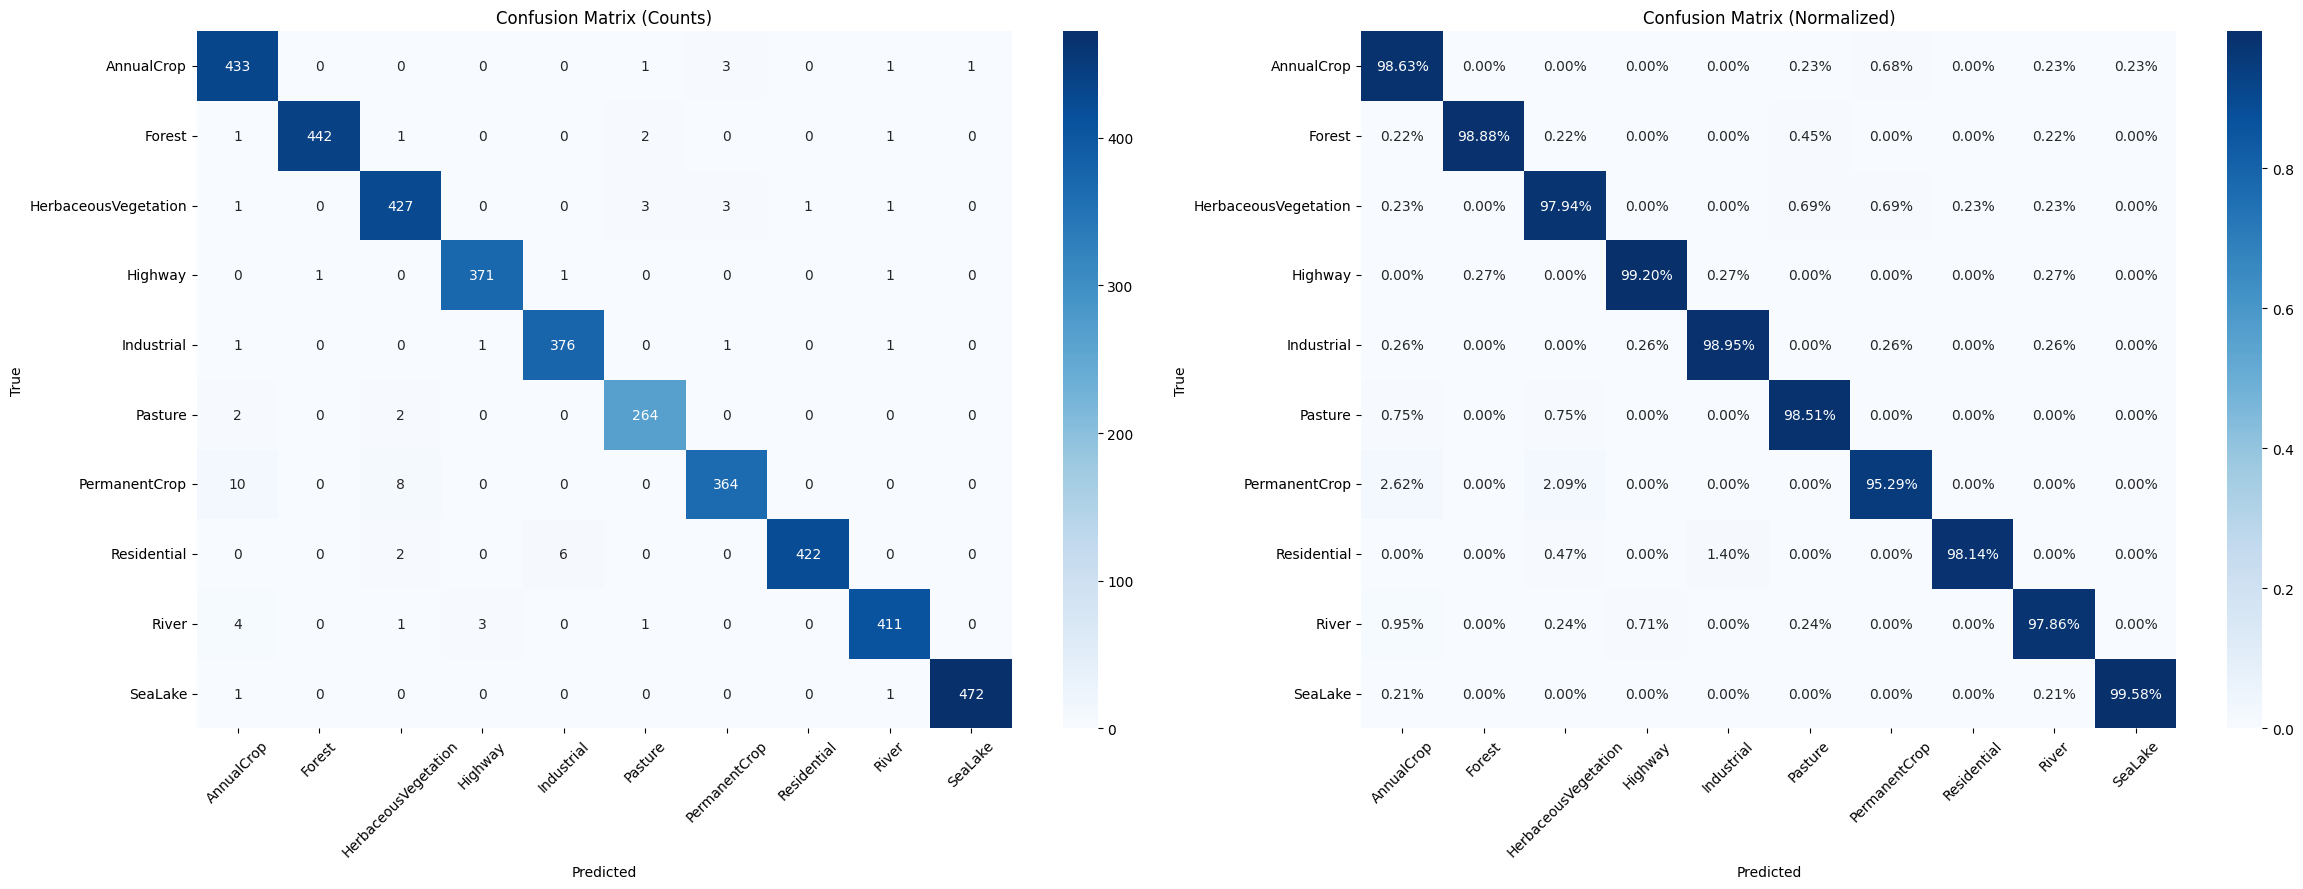

In [36]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(24, 9))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

## 11. Per-Class Accuracy

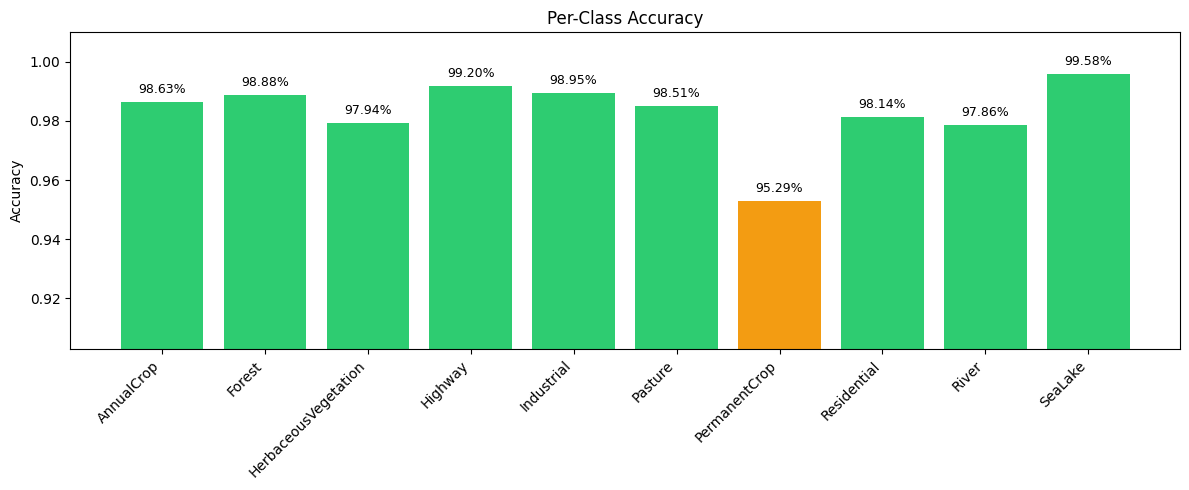

In [37]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if acc >= 0.97 else "#e74c3c" if acc < 0.93 else "#f39c12" for acc in per_class_acc]
bars = ax.bar(class_names, per_class_acc, color=colors)
ax.set_ylim(min(per_class_acc) - 0.05, 1.01)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy")
plt.xticks(rotation=45, ha="right")

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{acc:.2%}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_accuracy.png"), dpi=150)
plt.show()

## 12. Sample Predictions

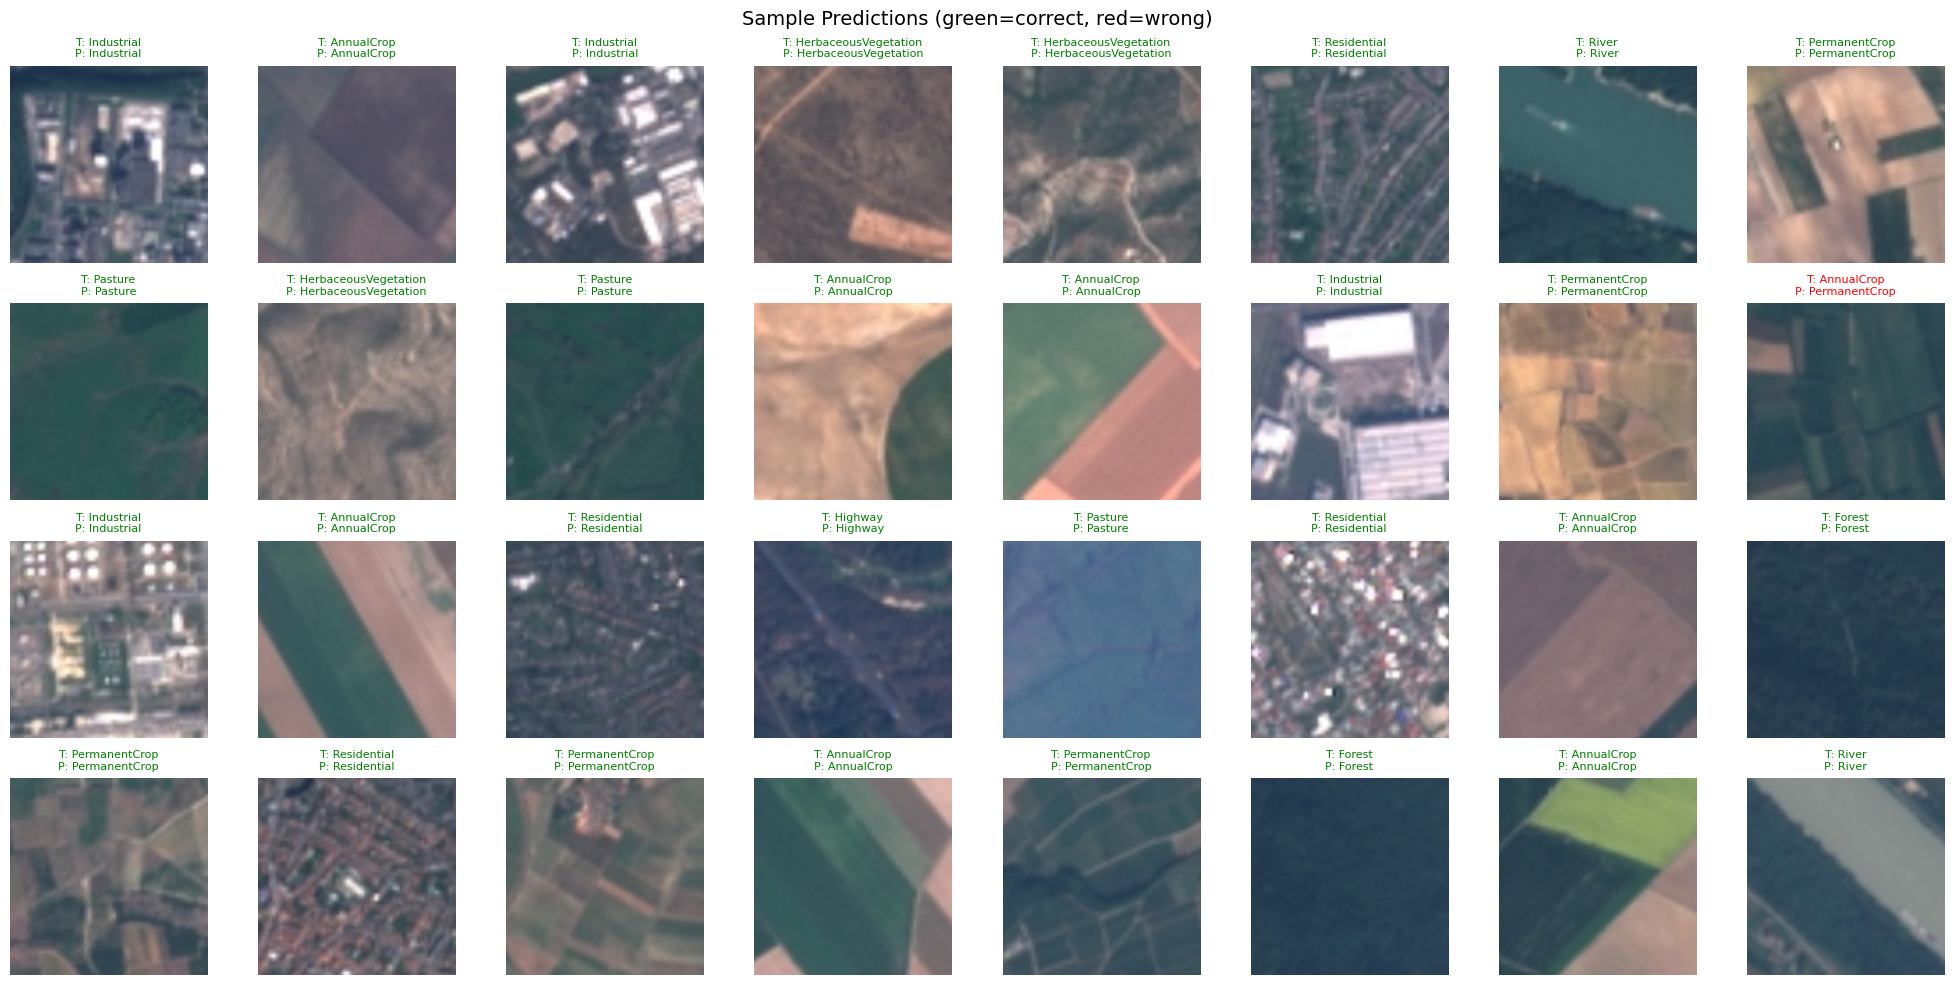

In [38]:
# Show test images with predictions
model.eval()
images_shown, num_rows, num_cols = 0, 4, 8

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 10))

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_gpu = inputs.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(inputs_gpu)
        _, preds = torch.max(outputs, 1)

        for i in range(inputs.size(0)):
            if images_shown >= num_rows * num_cols:
                break

            row, col = images_shown // num_cols, images_shown % num_cols
            img = inv_normalize(inputs[i]).permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            true_name = class_names[labels[i]]
            pred_name = class_names[preds[i].item()]
            correct = true_name == pred_name

            axes[row, col].imshow(img)
            axes[row, col].set_title(
                f"T: {true_name}\nP: {pred_name}",
                fontsize=8, color="green" if correct else "red"
            )
            axes[row, col].axis("off")
            images_shown += 1

        if images_shown >= num_rows * num_cols:
            break

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"), dpi=150)
plt.show()

---

## Iterative Development: V1 → V5

We went through 5 versions, testing different approaches to improve accuracy:

| Version | Normalization | Loss | Key Change | Test Accuracy | Epochs |
|---------|--------------|------|------------|---------------|--------|
| **V1 (Baseline)** | ImageNet | Standard CE | Full pipeline from scratch | **97.65%** | 100 |
| **V2** | ImageNet | Standard CE | Increased patience (8→12) | **97.65%** | 100 |
| **V3** | **Dataset-specific** | Standard CE | Computed EuroSAT mean/std | **97.58%** | 66 |
| **V4** | ImageNet | Standard CE | Better code structure + viz | **97.14%** | 39 |
| **V5** | ImageNet | **Label Smoothing CE** | **CutMix + TTA** | **98.32%** | 97 |

### What's New in V5

- **CutMix augmentation** — cuts a patch from one image and pastes it onto another, mixing labels proportionally. Forces the model to learn from partial views rather than relying on a single dominant region.
- **Label Smoothing (0.1)** — prevents overconfident predictions by distributing 0.1 probability mass across all classes. Makes the model more robust and better calibrated.
- **Test-Time Augmentation (TTA)** — averages predictions over 5 augmented views (original, H-flip, V-flip, +5° rotation, -5° rotation) for each test image.

### Key Findings Across All Versions

- **ImageNet normalization worked best** — even though EuroSAT images are satellite (not natural photos), the wider normalization range helped the model separate harder classes.
- **Dataset-specific normalization slightly hurt** — compressed the feature space, making it harder to distinguish similar land cover types.
- **CutMix + Label Smoothing gave the biggest boost** — V5 gained +0.67% over V1, matching closer to the 98.57% pretrained benchmark.

### From Scratch vs Pretrained — How Do We Compare?

| Method | Training | Test Accuracy | Gap |
|--------|----------|---------------|-----|
| EuroSAT paper (Helber et al., 2019) | **Pretrained ResNet-50** (ImageNet weights) | **98.57%** | — |
| Our V1 (Baseline) | From scratch (random init) | 97.65% | −0.92% |
| **Our V5 (CutMix + TTA)** | **From scratch (random init)** | **98.32%** | **−0.25%** |

**What this means:** Starting from random weights with no prior knowledge of natural images, our model reaches within **0.25%** of the pretrained benchmark. The pretrained model had already learned edge detectors, texture patterns, and color features from 1.2M ImageNet images — our model learned everything from the 27K EuroSAT images alone.

CutMix + Label Smoothing + TTA closed **73% of the gap** between from-scratch and pretrained performance.


---

### Per-Class Accuracy (Recall) Across Versions

| Class | V1 | V2 | V3 | V4 | **V5** | V5 vs V1 |
|-------|----|----|----|----|----|----|
| AnnualCrop | 97.95% | 97.95% | 97.72% | 97.49% | **98.63%** | **+0.68%** |
| Forest | 98.88% | 98.88% | 99.33% | 99.33% | **98.88%** | +0.00% |
| HerbaceousVegetation | 95.64% | 95.64% | 96.79% | 97.02% | **97.94%** | **+2.30%** |
| Highway | 98.13% | 98.13% | 97.86% | 97.59% | **99.20%** | **+1.07%** |
| Industrial | 97.63% | 97.63% | 98.16% | 97.11% | **98.95%** | **+1.32%** |
| Pasture | 96.64% | 96.64% | 98.13% | 97.39% | **98.51%** | **+1.87%** |
| PermanentCrop | 96.07% | 96.07% | 91.36% | 91.88% | **95.29%** | −0.78% |
| Residential | 98.60% | 98.60% | 99.53% | 99.30% | **98.14%** | −0.46% |
| River | 97.62% | 97.62% | 97.38% | 94.76% | **97.86%** | **+0.24%** |
| SeaLake | 98.73% | 98.73% | 98.95% | 98.73% | **99.58%** | **+0.85%** |

**V5 improvements over V1 (baseline):**
- **Biggest gains:** HerbaceousVegetation (+2.30%), Pasture (+1.87%), Industrial (+1.32%), Highway (+1.07%)
- **PermanentCrop** improved from V4's 91.88% back to 95.29% but still below V1's 96.07% — remains the hardest class
- **Forest** and **Residential** stayed roughly the same (already near 99%)
- **Overall:** 7 out of 10 classes improved, V5 is the best version for most classes


---

## References

1. **He, K., Zhang, X., Ren, S., & Sun, J.** (2016). *Deep Residual Learning for Image Recognition.* CVPR 2016. [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)

2. **Ioffe, S. & Szegedy, C.** (2015). *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift.* ICML 2015. [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)

3. **Helber, P., Bischke, B., Dengel, A., & Borth, D.** (2019). *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification.* IEEE JSTARS. [arXiv:1709.00029](https://arxiv.org/abs/1709.00029)

4. **Loshchilov, I. & Hutter, F.** (2019). *Decoupled Weight Decay Regularization.* ICLR 2019. [arXiv:1711.05101](https://arxiv.org/abs/1711.05101)

5. **He, K., Zhang, X., Ren, S., & Sun, J.** (2015). *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification.* ICCV 2015. [arXiv:1502.01852](https://arxiv.org/abs/1502.01852)


---

## Results Summary (V5 — Best Version)

| Metric | Score |
|--------|-------|
| **Test Accuracy (TTA)** | **98.32%** |
| **Best Val Accuracy** | **98.54%** |
| Macro F1 | 98.29% |
| Weighted F1 | 98.32% |
| Best Class | SeaLake (99.58%) |
| Hardest Class | PermanentCrop (95.29%) |

### Key Takeaways
- ResNet50 from scratch (no pretrained weights) — **only 0.25% below the pretrained benchmark** of 98.57%
- CutMix + Label Smoothing + TTA added **+0.67% accuracy** over the V1 baseline
- Kaiming init + BatchNorm enabled stable training of 50+ layers from random weights
- ImageNet normalization outperformed dataset-specific normalization
- Satellite-specific augmentations (vertical flips, rotation) were critical

---

## Live Demo → Switch to Streamlit
